# GNN

Trains STGATv2 across the 5 folds in `folds.json` and reports per-class F1 with mean and std across folds.

## Imports

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

In [2]:
sys.path.insert(0, str(Path.cwd().parent))

In [3]:
from src.utils.config.config import Config
from src.classifier.common.constants import ACTION_NAMES, NUM_NODES, NUM_KEYPOINTS, OBJECT_NODE_IDX
from src.classifier.common.graph import build_adjacency
from src.classifier.common.augment import SkeletonAugment
from src.classifier.gnn.dataset import GNNHOIDataset, NODE_CHANNELS
from src.classifier.gnn.model import STGATv2
from src.classifier.gnn.trainer import GNNTrainer

## Config

In [4]:
SEED = 42

config_loader = Config()
cfg = config_loader.load_config()
hp = cfg.gnn

dataset_root = cfg.project_root / cfg.paths.dataset / "CafeV1"
clips_root   = dataset_root / "Clips"
cache_root   = dataset_root / "cache" / "keypoints"
folds_path   = dataset_root / "folds.json"
runs_root    = cfg.project_root / "runs" / "gnn"
runs_root.mkdir(parents=True, exist_ok=True)

print(f"device: {cfg.device}")
print(f"hp: {hp}")

device: cuda
hp: GNNConfig(seq_len=16, stride=8, hidden=64, heads=4, dropout=0.1, lr=0.001, weight_decay=0.0001, batch_size=32, epochs=50, patience=10, hflip_p=0.5, jitter_std=0.02, obj_dropout_p=0.1)


## Folds

In [5]:
def load_folds(path):
    with open(path) as f:
        return json.load(f)

def split(folds_data, val_fold):
    val = folds_data["folds"][val_fold]
    train = [c for i, f in enumerate(folds_data["folds"]) if i != val_fold for c in f]
    return train, val

In [6]:
folds_data = load_folds(folds_path)
K = folds_data["k"]
print(f"loaded {K}-fold split, seed {folds_data['seed']}")

loaded 5-fold split, seed 42


## Smoke test

Build one fold and check shapes before training all 5.

In [7]:
train_clips, val_clips = split(folds_data, val_fold=0)

train_set = GNNHOIDataset(clips_root, cache_root, train_clips, ACTION_NAMES,
                          seq_len=hp.seq_len, stride=hp.stride)
val_set   = GNNHOIDataset(clips_root, cache_root, val_clips, ACTION_NAMES,
                          seq_len=hp.seq_len, stride=hp.stride)

print(f"train: {len(train_set)} windows, {dict(zip(ACTION_NAMES, train_set.label_counts()))}")
print(f"val:   {len(val_set)} windows, {dict(zip(ACTION_NAMES, val_set.label_counts()))}")

x, y = train_set[0]
print(f"sample x: {tuple(x.shape)}  y: {y.item()} ({ACTION_NAMES[y.item()]})")
print(f"diagnostics: {dict(train_set._diag)}")

train: 2829 windows, {'idle': 1594, 'using_laptop': 54, 'using_phone': 778, 'reading': 403}
val:   720 windows, {'idle': 393, 'using_laptop': 17, 'using_phone': 209, 'reading': 101}
sample x: (16, 18, 8)  y: 0 (idle)
diagnostics: {'segments_total': 1519, 'dropped_too_short': 503}


In [8]:
adj = build_adjacency(NUM_NODES)
model = STGATv2(in_channels=NODE_CHANNELS, num_classes=len(ACTION_NAMES),
                hidden=hp.hidden, heads=hp.heads, dropout=hp.dropout)

xb = x.unsqueeze(0).to(cfg.device)
adj_d = adj.to(cfg.device)
model = model.to(cfg.device)

with torch.no_grad():
    logits = model(xb, adj_d)
print(f"forward ok. logits: {tuple(logits.shape)}")
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

forward ok. logits: (1, 4)
params: 87,876


## 5-fold training

In [9]:
def run_fold(val_fold):
    torch.manual_seed(SEED + val_fold)
    np.random.seed(SEED + val_fold)

    train_clips, val_clips = split(folds_data, val_fold)

    train_aug = SkeletonAugment(
        hflip_p=hp.hflip_p,
        jitter_std=hp.jitter_std,
        obj_dropout_p=hp.obj_dropout_p,
        num_keypoints=NUM_KEYPOINTS,
        object_node_idx=OBJECT_NODE_IDX,
    )

    train_set = GNNHOIDataset(clips_root, cache_root, train_clips, ACTION_NAMES,
                              seq_len=hp.seq_len, stride=hp.stride, augment=train_aug)
    val_set   = GNNHOIDataset(clips_root, cache_root, val_clips, ACTION_NAMES,
                              seq_len=hp.seq_len, stride=hp.stride)

    model = STGATv2(in_channels=NODE_CHANNELS, num_classes=len(ACTION_NAMES),
                    hidden=hp.hidden, heads=hp.heads, dropout=hp.dropout)

    trainer = GNNTrainer(
        model=model,
        train_set=train_set,
        val_set=val_set,
        action_names=ACTION_NAMES,
        adj=adj,
        lr=hp.lr, weight_decay=hp.weight_decay,
        batch_size=hp.batch_size, epochs=hp.epochs, patience=hp.patience,
        device=cfg.device,
    )

    save_path = runs_root / f"fold{val_fold}_best.pt"
    history, best_f1 = trainer.fit(save_path=save_path)

    trainer.model.load_state_dict(torch.load(save_path, map_location=cfg.device))
    return trainer.evaluate(), trainer.confusion_matrix()

In [10]:
fold_reports = []
fold_cms = []
for k in range(K):
    print(f"\n{'='*60}\nFold {k}\n{'='*60}")
    report, cm = run_fold(k)
    fold_reports.append(report)
    fold_cms.append(cm)
    print(f"\nFold {k} per class F1:")
    for name in ACTION_NAMES:
        print(f"  {name:15s} {report[name]['f1']:.3f}  (support {report[name]['support']})")


Fold 0
Epoch   1 | train 0.8976/0.821 | val 0.2631/0.975 | macroF1 0.953
Epoch   2 | train 0.4174/0.933 | val 0.1935/0.975 | macroF1 0.958
Epoch   3 | train 0.3493/0.942 | val 0.1781/0.978 | macroF1 0.960
Epoch   4 | train 0.3587/0.939 | val 0.1610/0.981 | macroF1 0.962
Epoch   5 | train 0.3552/0.940 | val 0.1734/0.976 | macroF1 0.959
Epoch   6 | train 0.3484/0.948 | val 0.1910/0.981 | macroF1 0.962
Epoch   7 | train 0.3113/0.946 | val 0.1651/0.981 | macroF1 0.962
Epoch   8 | train 0.3245/0.938 | val 0.1625/0.975 | macroF1 0.958
Epoch   9 | train 0.3469/0.938 | val 0.1896/0.981 | macroF1 0.962
Epoch  10 | train 0.3042/0.943 | val 0.1853/0.981 | macroF1 0.962
Epoch  11 | train 0.3186/0.932 | val 0.2044/0.975 | macroF1 0.957
Epoch  12 | train 0.3199/0.936 | val 0.1924/0.965 | macroF1 0.906
Epoch  13 | train 0.3350/0.943 | val 0.1780/0.981 | macroF1 0.962
Epoch  14 | train 0.3523/0.936 | val 0.2041/0.965 | macroF1 0.906
Early stop at epoch 14. Best macroF1 0.962

Fold 0 per class F1:
  i

## Summary

Per-class F1 across folds with mean and std. Macro F1 is the average across the 4 action classes.

In [11]:
fold_cols = [f"fold_{k}" for k in range(K)]
rows = {fc: [rep[name]["f1"] for name in ACTION_NAMES]
        for fc, rep in zip(fold_cols, fold_reports)}

df = pd.DataFrame(rows, index=ACTION_NAMES)
df.loc["macro"] = df.mean(axis=0)
df["mean"] = df[fold_cols].mean(axis=1)
df["std"]  = df[fold_cols].std(axis=1)
df.round(3)

,fold_0,fold_1,fold_2,fold_3,fold_4,mean,std
idle,0.982,0.992,0.998,0.992,0.979,0.989,0.008
using_laptop,0.919,0.791,1.000,1.000,1.000,0.942,0.092
using_phone,0.998,0.988,0.979,0.986,0.963,0.983,0.013
reading,0.949,0.996,0.963,0.995,0.967,0.974,0.021
macro,0.962,0.942,0.985,0.993,0.977,0.972,0.020


## Confusion matrix

Summed across all 5 folds. Rows are the true class, columns are the predicted class. Diagonal is correct. Off-diagonal tells you what each class gets confused with.

The row-normalized version below shows the per-class recall along the diagonal and the confusion as fractions, which is easier to read than raw counts when classes are imbalanced.

In [12]:
total_cm = sum(fold_cms)
cm_df = pd.DataFrame(total_cm, index=ACTION_NAMES, columns=ACTION_NAMES)
cm_df.index.name = "true \\ pred"
cm_df

,idle,using_laptop,using_phone,reading
true \ pred,,,,
idle,1971,3,10,3
using_laptop,5,65,1,0
using_phone,11,3,970,3
reading,12,0,6,486


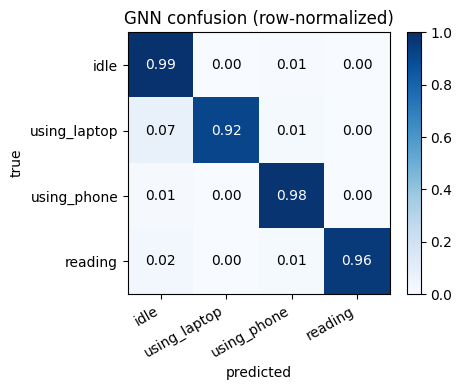

In [14]:
import matplotlib.pyplot as plt

row_sums = total_cm.sum(axis=1, keepdims=True)
norm_cm = total_cm / np.where(row_sums == 0, 1, row_sums)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(norm_cm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(ACTION_NAMES)))
ax.set_yticks(range(len(ACTION_NAMES)))
ax.set_xticklabels(ACTION_NAMES, rotation=30, ha="right")
ax.set_yticklabels(ACTION_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("GNN confusion (row-normalized)")

for i in range(len(ACTION_NAMES)):
    for j in range(len(ACTION_NAMES)):
        ax.text(j, i, f"{norm_cm[i, j]:.2f}", ha="center", va="center",
                color="white" if norm_cm[i, j] > 0.5 else "black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Save results

Writes a single JSON with all fold reports and confusion matrices. comparison.ipynb reads from these.

In [15]:
from src.classifier.common import results

results.save(
    runs_root / "results.json",
    model_name="gnn",
    action_names=ACTION_NAMES,
    fold_reports=fold_reports,
    fold_cms=fold_cms,
)
print(f"saved {runs_root / 'results.json'}")

saved C:\Research\Prototype\skeleton-based-hoi-recognition\runs\gnn\results.json
